In [ ]:
# Setup
!pip install -q ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
# Load the dataset
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets

df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
# Structural overview (data types, row meaning)

print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing values per column:
 age                0
job   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,44923,11,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,43354,3,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,32191,2,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [ ]:
# Hidden missing values: the "unknown" category
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "y"]

for col in df.columns:
    if col == "y":
        continue
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        pct = n_missing / len(df) * 100
        print(f"{col}: {n_missing} missing ({pct:.2f}%)")

job: 288 missing (0.64%)
education: 1857 missing (4.11%)
contact: 13020 missing (28.80%)
poutcome: 36959 missing (81.75%)


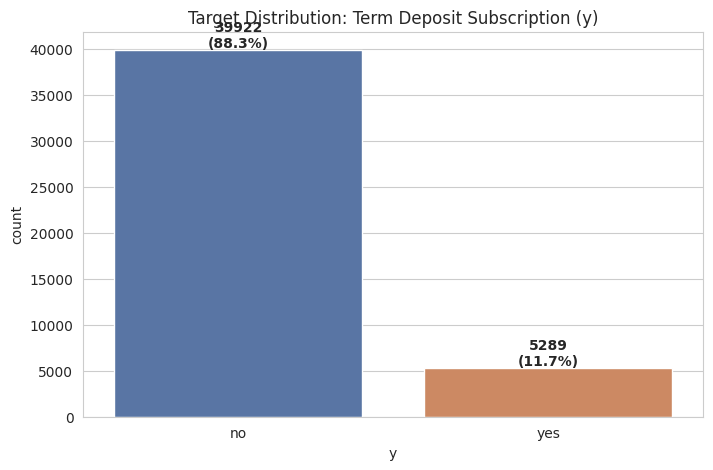

In [ ]:
# Target class distribution
target_col = "y"

counts = df[target_col].value_counts()
pct = df[target_col].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
sns.countplot(data=df, x=target_col, ax=ax, hue=target_col, palette=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts):
    ax.text(i, v + 300, f"{v}\n({pct.iloc[i]:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Target Distribution: Term Deposit Subscription (y)")
plt.show()

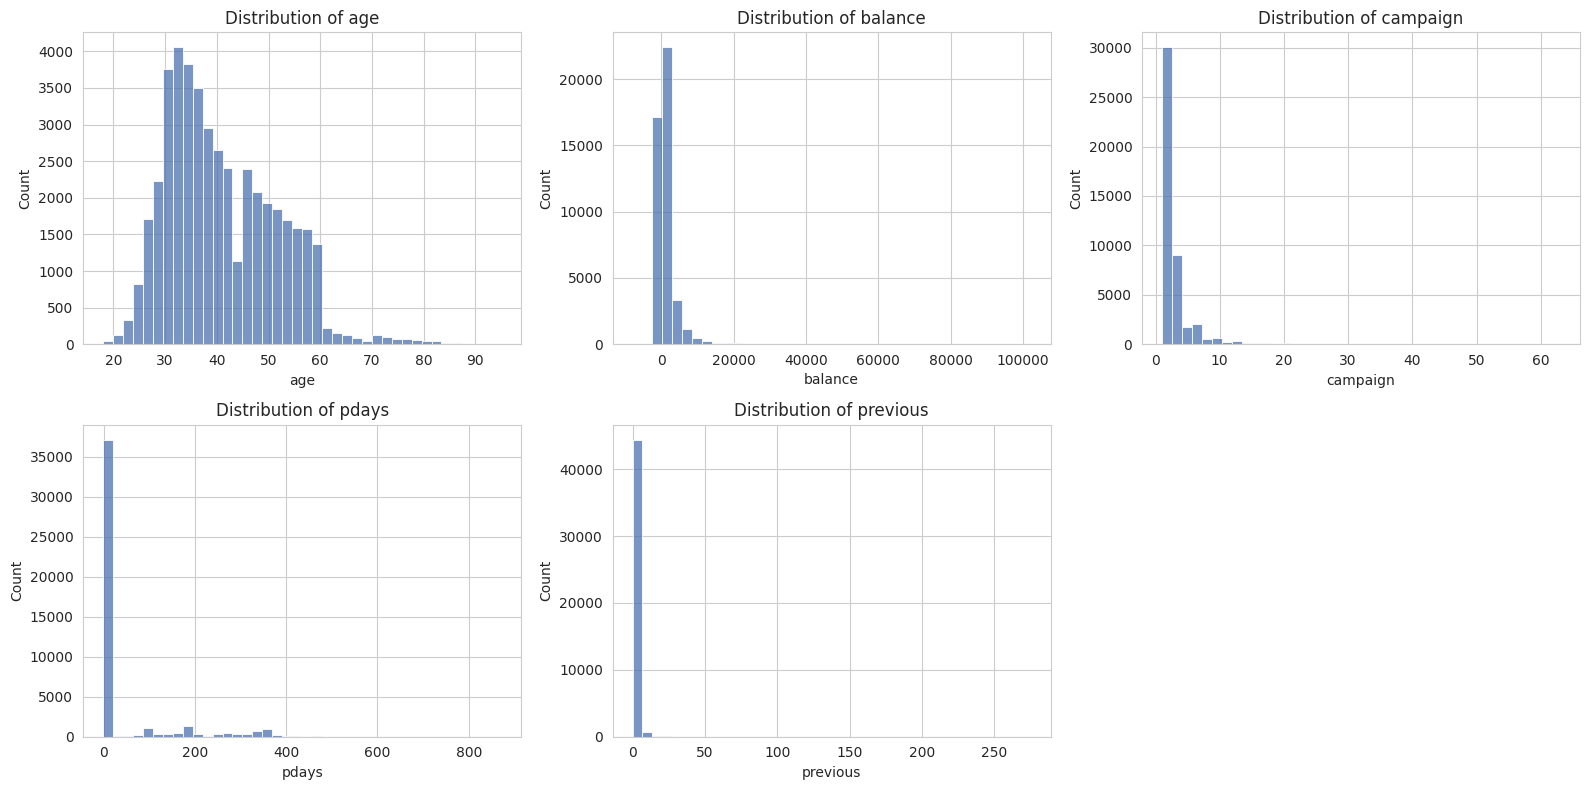

In [ ]:
# Numeric feature distributions
numeric_cols = ["age", "balance", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

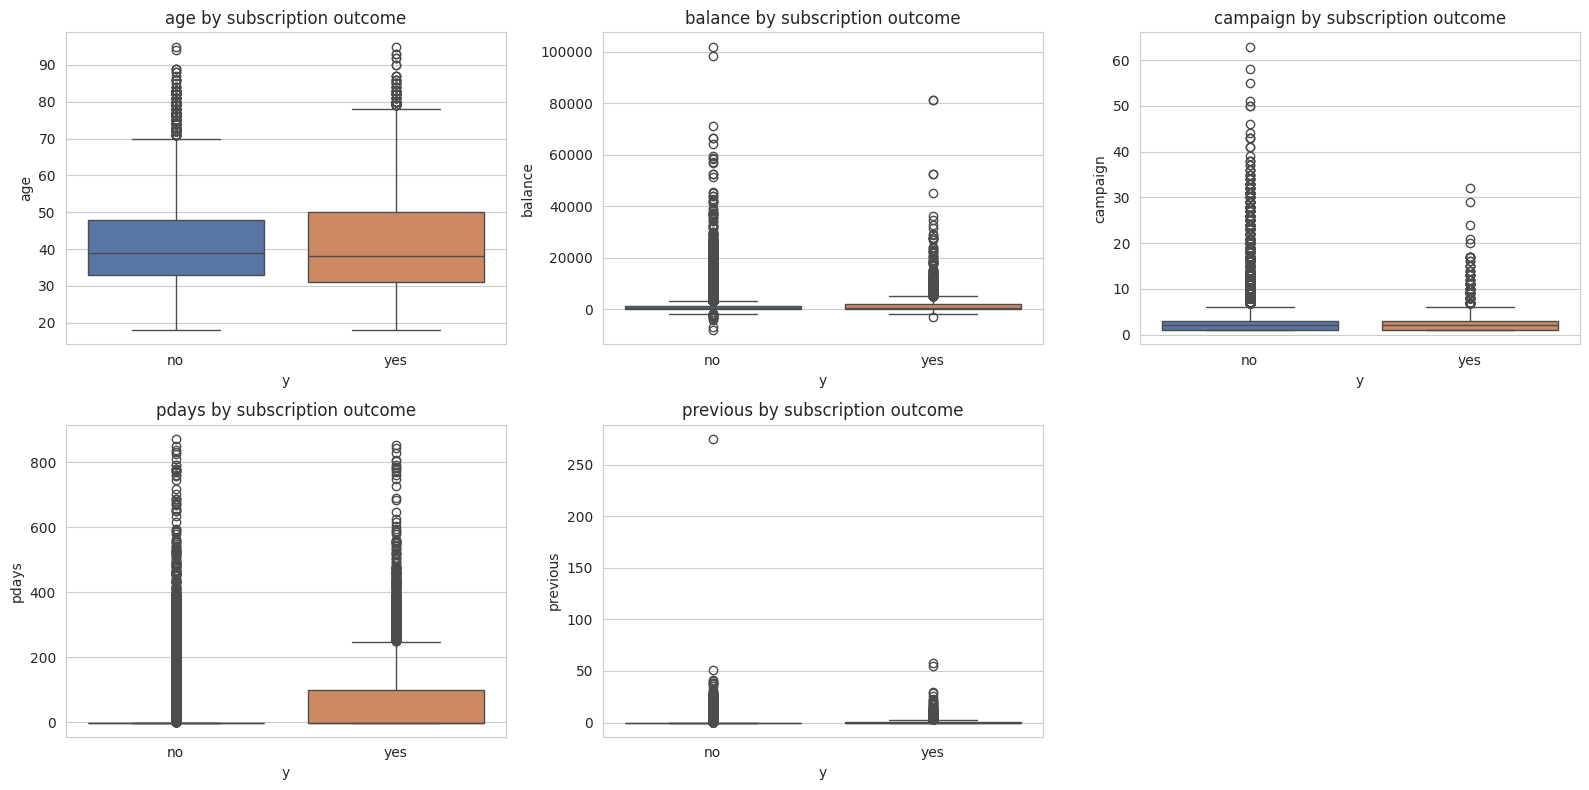

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,age,10.5,70.5,487,1.08
1,balance,-1962.0,3462.0,4729,10.46
2,campaign,-2.0,6.0,3064,6.78
3,pdays,-1.0,-1.0,8257,18.26
4,previous,0.0,0.0,8257,18.26


In [ ]:
# Numeric features vs. target
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i], hue=target_col, palette=["#4C72B0", "#DD8452"])
    axes[i].set_title(f"{col} by subscription outcome")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append([col, round(lower, 1), round(upper, 1), n_out, round(n_out / len(data) * 100, 2)])
    return pd.DataFrame(rows, columns=["feature", "lower_bound", "upper_bound", "n_outliers", "pct_outliers"])

iqr_outlier_summary(df, numeric_cols)

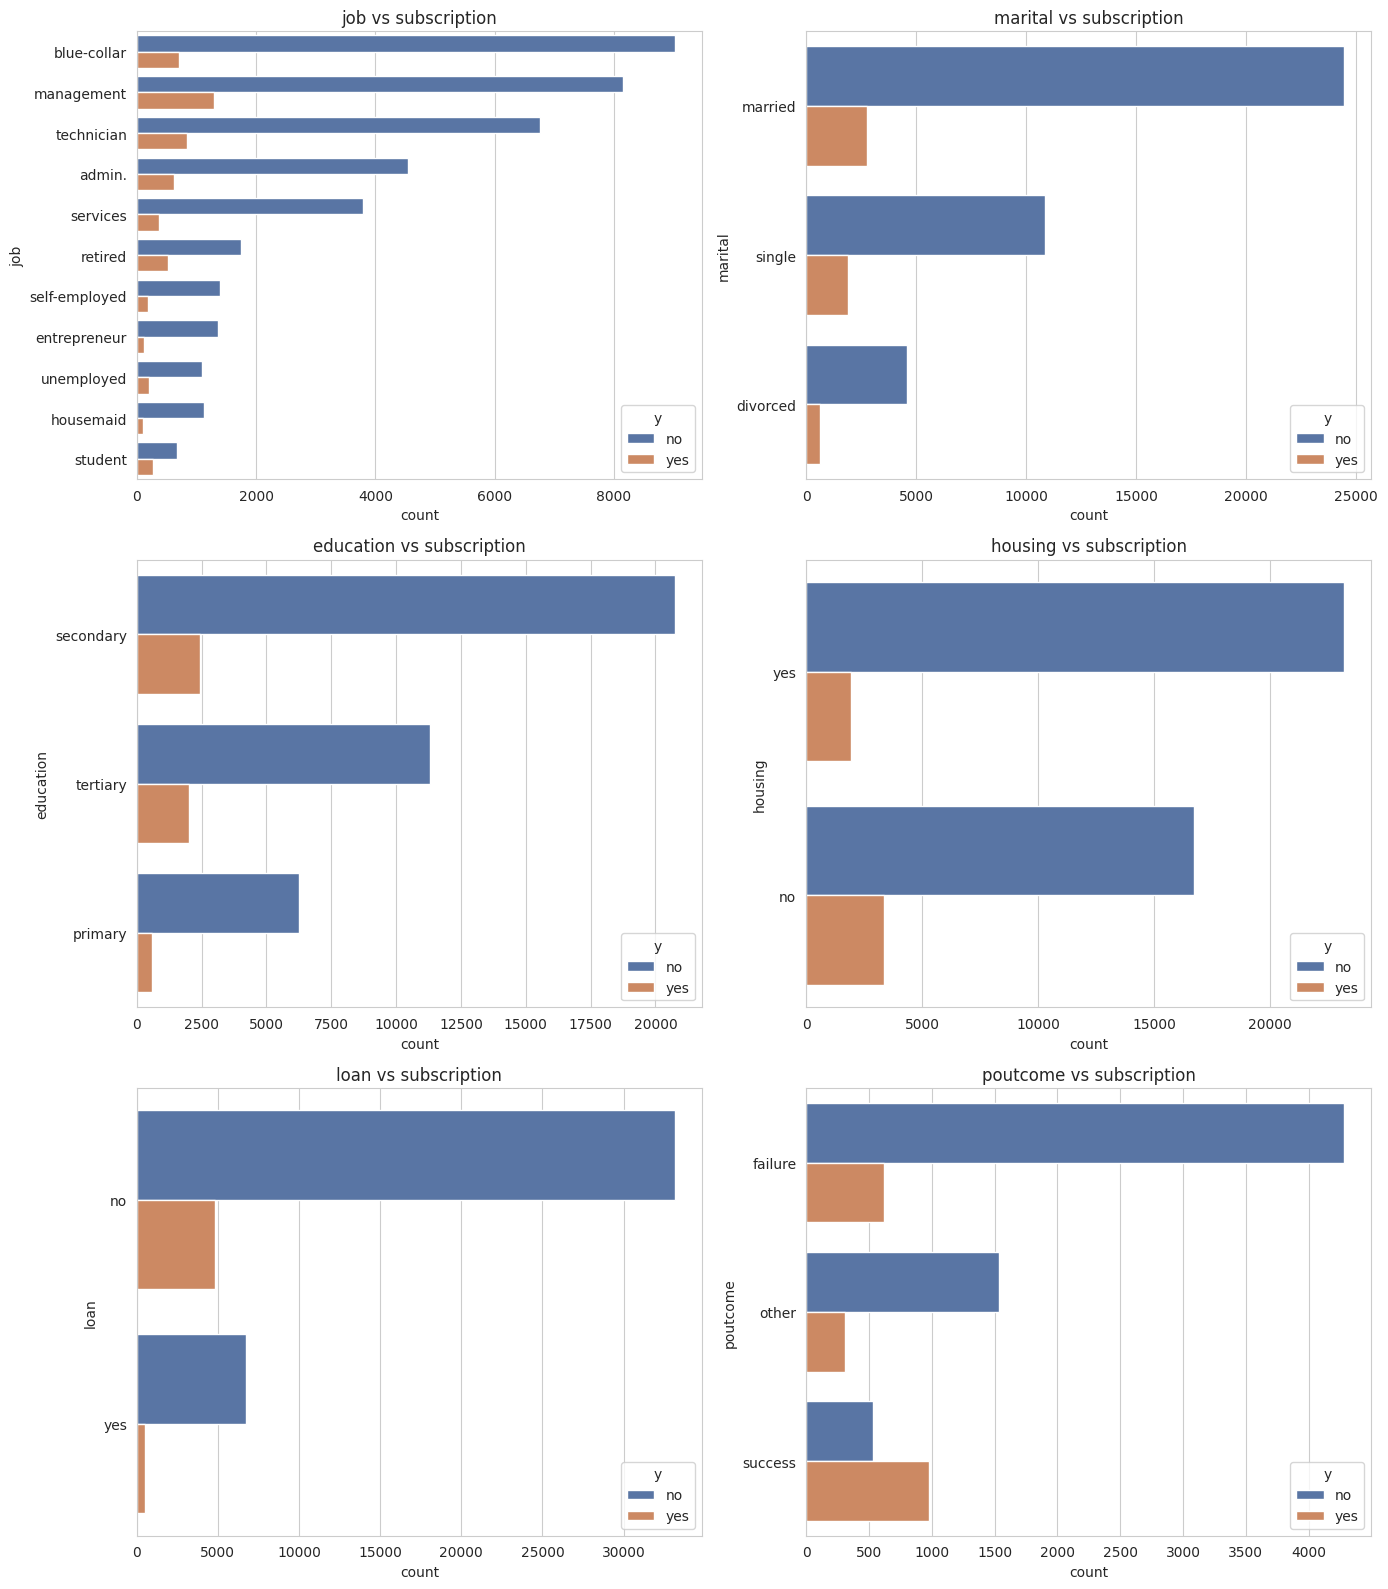

In [ ]:
# Categorical features vs. target
cat_to_plot = ["job", "marital", "education", "housing", "loan", "poutcome"]

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(cat_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue=target_col, order=order, ax=axes[i],
                  palette=["#4C72B0", "#DD8452"])
    axes[i].set_title(f"{col} vs subscription")
plt.tight_layout()
plt.show()

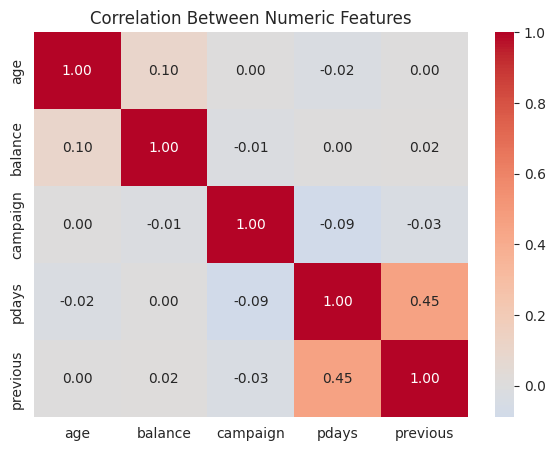

In [ ]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

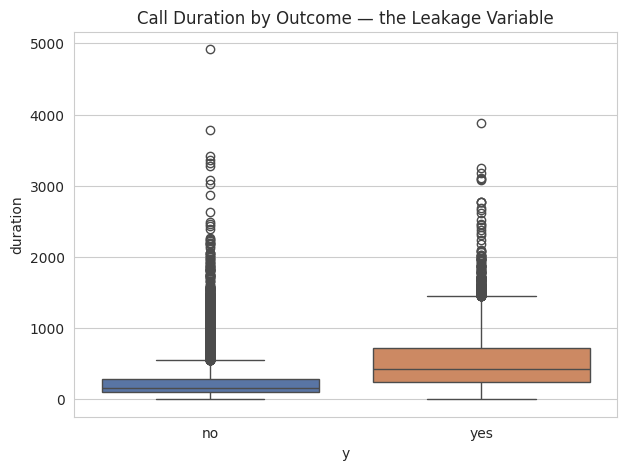

y
no     164.0
yes    426.0
Name: duration, dtype: float64


In [ ]:
# Why duration must be treated as leakage
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x=target_col, y="duration", hue=target_col, palette=["#4C72B0", "#DD8452"])
plt.title("Call Duration by Outcome — the Leakage Variable")
plt.show()

print(df.groupby(target_col)["duration"].median())